# **Generate some Rainfall images**

In [44]:
# Imports
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import re

from matplotlib.colors import ListedColormap, BoundaryNorm

# Custom CMAP
def make_cmap(high_vals=False, very_high_vals=False, low_vals=False):

    precip_clevs = [0, 1, 2, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50, 70, 100, 150]

    if high_vals:
        precip_clevs = [0, 20, 40, 60, 80, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400, 500]

    if very_high_vals:
        precip_clevs = [500, 600, 700, 800, 900, 1000, 1100, 1200,
                        1300, 1400, 1500, 1700, 1900, 2100, 2300, 2500]

    if low_vals:
        precip_clevs = [0, 2, 4, 6, 8, 10, 12, 14, 16, 19, 20, 22, 24, 26, 28, 30]

    tc_colours = [
        (255/255,255/255,255/255),
        (169/255,209/255,222/255),
        (137/255,190/255,214/255),
        (105/255,160/255,194/255),
        (93/255,168/255,98/255),
        (128/255,189/255,100/255),
        (165/255,196/255,134/255),
        (233/255,245/255,105/255),
        (245/255,191/255,105/255),
        (245/255,112/255,105/255),
        (245/255,105/255,149/255),
        (240/255,93/255,154/255),
        (194/255,89/255,188/255),
        (66/255,57/255,230/255),
        (24/255,17/255,153/255),
        (9/255,5/255,87/255),
    ]

    precip_cmap = ListedColormap(tc_colours[:len(precip_clevs)])
    precip_norm = BoundaryNorm(precip_clevs, precip_cmap.N, extend='max')

    return precip_cmap, precip_norm

In [13]:
# Folder containing the TIF files
folder = '../data/processed/chirps'

# Get list of TIF files and sort them
files = [f for f in os.listdir(folder) if f.endswith('.tif')]
files.sort()

# Pick the first 10 files
sample_files = [os.path.join(folder, x) for x in files[:10]]

print(sample_files)

['../data/processed/chirps\\chirps-v3.0.1981.01_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.02_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.03_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.04_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.05_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.06_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.07_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.08_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.09_mozambique.tif', '../data/processed/chirps\\chirps-v3.0.1981.10_mozambique.tif']


## **Makes Multiple Plots**

In [60]:
i = 0 
for sample_file in sample_files: 
    i+=1 
    # Load the data using rasterio
    with rasterio.open(sample_file) as src:
        data = src.read(1)  # Read the first band
        # Mask invalid data (CHIRPS uses -9999 for no data)
        data = np.ma.masked_where(data < 0, data)
        # Get the extent from the transform
        transform = src.transform
        left = transform[2]
        top = transform[5]
        right = left + transform[0] * src.width
        bottom = top + transform[4] * src.height  # dy is negative
        extent = [left, right, bottom, top]
    
    # Get the colormap and norm, adapted for monthly rainfall (high values)
    precip_cmap, precip_norm = make_cmap(high_vals=True)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(data, cmap=precip_cmap, norm=precip_norm, extent=extent, origin='upper')
    plt.colorbar(im, ax=ax, label='Rainfall (mm/month)', extend='max')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    # Extract year and month from filename for title
    match = re.search(r'(\d{4})\.(\d{2})', sample_file)
    if match:
        title = f'CHIRPS Monthly Rainfall {match.group(1)}-{match.group(2)}'
        ax.set_title(title)
    
    ax.grid(True)
    
    # Create output folder if needed
    os.makedirs('../images/rainfall_viz', exist_ok=True)
    
    # Save the plot
    save_path = os.path.join('../images/rainfall_viz', f'plot{i}.png')
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)  # Close to free memory
    
    print(f"Plot saved to {save_path}")

Plot saved to ../images/rainfall_viz\plot1.png
Plot saved to ../images/rainfall_viz\plot2.png
Plot saved to ../images/rainfall_viz\plot3.png
Plot saved to ../images/rainfall_viz\plot4.png
Plot saved to ../images/rainfall_viz\plot5.png
Plot saved to ../images/rainfall_viz\plot6.png
Plot saved to ../images/rainfall_viz\plot7.png
Plot saved to ../images/rainfall_viz\plot8.png
Plot saved to ../images/rainfall_viz\plot9.png
Plot saved to ../images/rainfall_viz\plot10.png
Plot saved to ../images/rainfall_viz\plot11.png
Plot saved to ../images/rainfall_viz\plot12.png
Plot saved to ../images/rainfall_viz\plot13.png
Plot saved to ../images/rainfall_viz\plot14.png
Plot saved to ../images/rainfall_viz\plot15.png
Plot saved to ../images/rainfall_viz\plot16.png
Plot saved to ../images/rainfall_viz\plot17.png
Plot saved to ../images/rainfall_viz\plot18.png
Plot saved to ../images/rainfall_viz\plot19.png
Plot saved to ../images/rainfall_viz\plot20.png
Plot saved to ../images/rainfall_viz\plot21.png
P

## **Generates a single Plot**

Text(0, 0.5, 'Latitude')

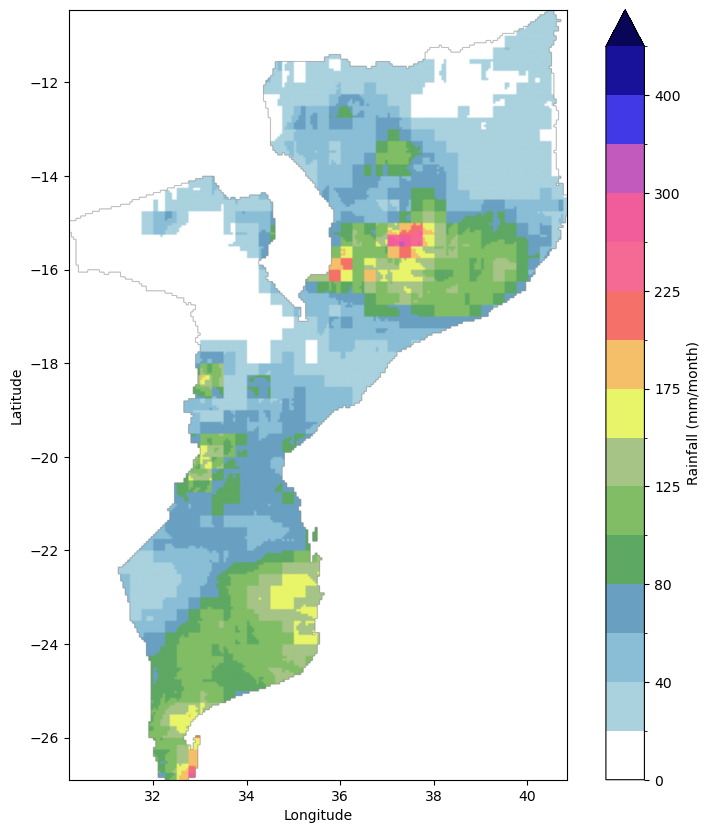

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(data, cmap=precip_cmap, norm=precip_norm, extent=extent, origin='upper')
plt.colorbar(im, ax=ax, label='Rainfall (mm/month)', extend='max')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# **Statistical anaysis of the Rainfall data**

In [28]:
# make the file list
sample_files = [os.path.join(folder, x) for x in files]

chirps_list  = []
chirps_times = []

for fpath in sample_files:
    stem  = Path(fpath).stem                    # chirps-v3.0.1981.01_mozambique
    parts = stem.replace("_mozambique", "").split(".")
    year  = int(parts[-2])
    month = int(parts[-1])

    da = rioxarray.open_rasterio(fpath, masked=True).squeeze("band", drop=True)
    arr = da.values.astype(np.float32)
    arr[arr <= CHIRPS_NODATA] = np.nan

    chirps_list.append(arr)
    chirps_times.append(pd.Timestamp(year=year, month=month, day=1))

    # Grab lat/lon coordinates once from the first file
    if len(chirps_times) == 1:
        lats = da.y.values
        lons = da.x.values

chirps_times = pd.DatetimeIndex(chirps_times)
chirps_data  = np.stack(chirps_list, axis=0)        # (T, H, W)

print(f"  Loaded shape : {chirps_data.shape}")
print(f"  Time range   : {chirps_times[0].date()} → {chirps_times[-1].date()}")
print(f"  Lat range    : {lats.min():.2f}° → {lats.max():.2f}°")
print(f"  Lon range    : {lons.min():.2f}° → {lons.max():.2f}°")


  Loaded shape : (541, 329, 213)
  Time range   : 1981-01-01 → 2026-01-01
  Lat range    : -26.88° → -10.48°
  Lon range    : 30.23° → 40.83°


In [29]:
# ---------------------------------------------------------------------------
# Step 2 — Basic statistics
# ---------------------------------------------------------------------------
print("\n── Basic statistics ─────────────────────────────────")
valid_mask = ~np.isnan(chirps_data)
print(f"  Total pixels/timestep : {chirps_data.shape[1] * chirps_data.shape[2]:,}")
print(f"  Valid pixels/timestep : {valid_mask[0].sum():,}")
print(f"  NaN fraction          : {np.isnan(chirps_data).mean():.1%}")
print(f"  Global min            : {np.nanmin(chirps_data):.2f} mm")
print(f"  Global max            : {np.nanmax(chirps_data):.2f} mm")
print(f"  Global mean           : {np.nanmean(chirps_data):.2f} mm/month")
print(f"  Global std            : {np.nanstd(chirps_data):.2f} mm")

# Monthly stats table
monthly_means = pd.Series(
    [np.nanmean(chirps_data[i]) for i in range(len(chirps_times))],
    index=chirps_times
)
print("\n  Per-year mean rainfall summary:")
print(monthly_means.resample("YE").sum().describe().round(1).to_string())


── Basic statistics ─────────────────────────────────
  Total pixels/timestep : 70,077
  Valid pixels/timestep : 27,745
  NaN fraction          : 60.4%
  Global min            : 0.00 mm
  Global max            : 1292.70 mm
  Global mean           : 91.60 mm/month
  Global std            : 113.15 mm

  Per-year mean rainfall summary:
count      46.0
mean     1077.3
std       195.7
min       274.7
25%       968.2
50%      1091.9
75%      1187.5
max      1449.3


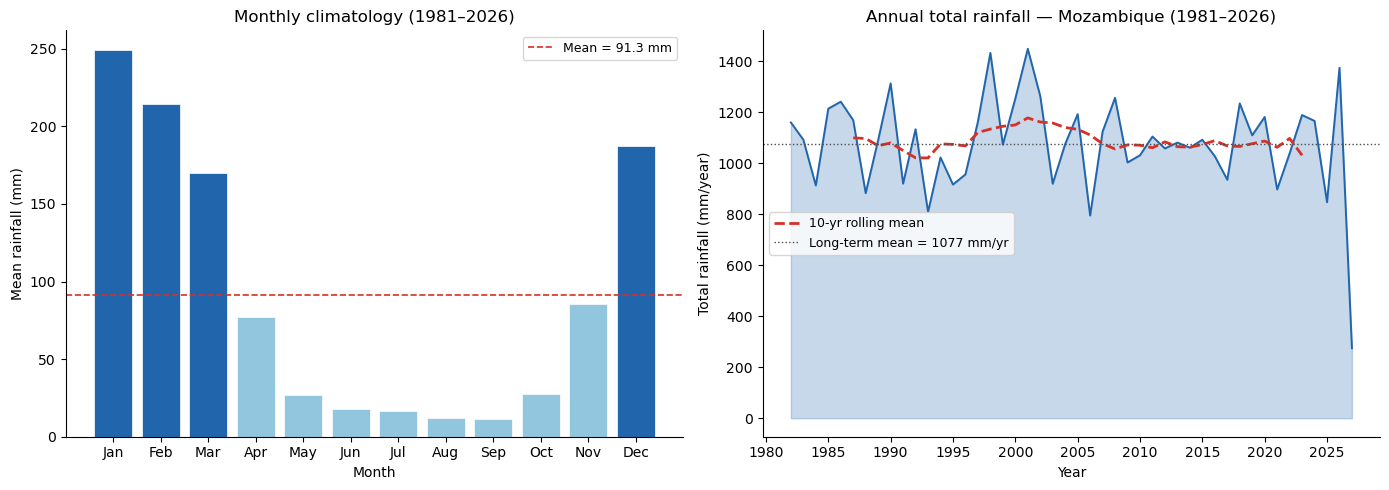

  Saved: 01_temporal_analysis.png


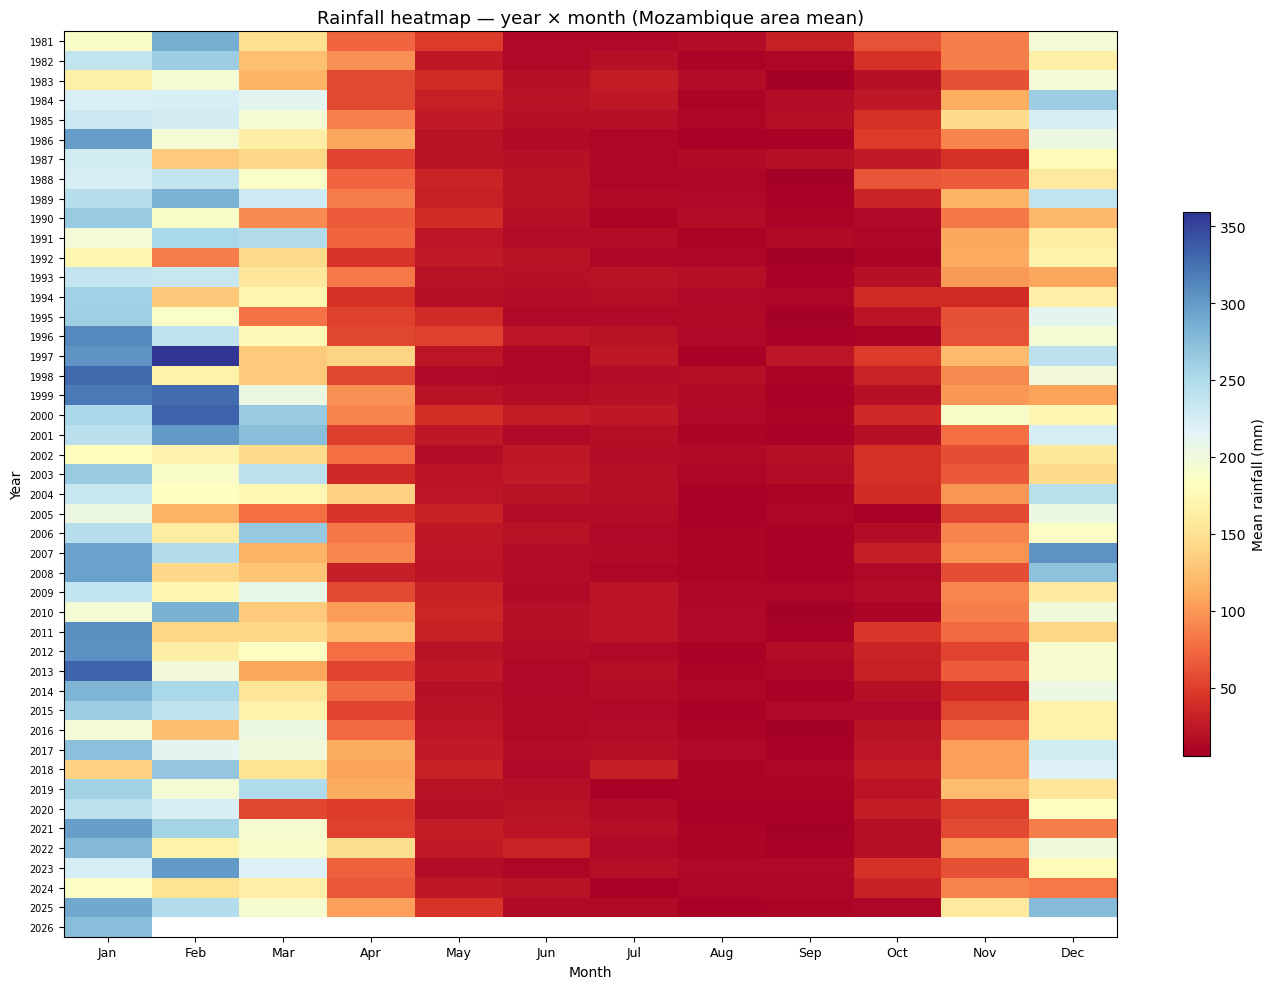

  Saved: 02_seasonal_heatmap.png


In [36]:
# ---------------------------------------------------------------------------
# Step 3 — Temporal analysis
# ---------------------------------------------------------------------------
# ── 3a. Monthly climatology (average rainfall per calendar month)
clim_monthly = np.array([
    np.nanmean(chirps_data[chirps_times.month == m])
    for m in range(1, 13)
])
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — monthly climatology
ax = axes[0]
colors = ["#2166ac" if c > np.mean(clim_monthly) else "#92c5de" for c in clim_monthly]
bars = ax.bar(month_labels, clim_monthly, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(clim_monthly.mean(), color="#d73027", linewidth=1.2, linestyle="--",
           label=f"Mean = {clim_monthly.mean():.1f} mm")
ax.set_title("Monthly climatology (1981–2026)", fontsize=12)
ax.set_ylabel("Mean rainfall (mm)")
ax.set_xlabel("Month")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

# ── 3b. Annual total time series
annual_totals = monthly_means.resample("YE").sum()

ax = axes[1]

ax.fill_between(annual_totals.index, annual_totals.values,
                alpha=0.25, color="#2166ac")
ax.plot(annual_totals.index, annual_totals.values,
        color="#2166ac", linewidth=1.4)
# 10-year rolling mean
rolling = annual_totals.rolling(10, center=True).mean()
ax.plot(rolling.index, rolling.values,
        color="#d73027", linewidth=2, linestyle="--", label="10-yr rolling mean")
ax.axhline(annual_totals.mean(), color="#4d4d4d", linewidth=1,
           linestyle=":", label=f"Long-term mean = {annual_totals.mean():.0f} mm/yr")
ax.set_title("Annual total rainfall — Mozambique (1981–2026)", fontsize=12)
ax.set_ylabel("Total rainfall (mm/year)")
ax.set_xlabel("Year")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join('../images/rainfall_viz', "01_temporal_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: 01_temporal_analysis.png")

# ── 3c. Seasonal decomposition heatmap (year × month)
pivot = monthly_means.to_frame("rain")
pivot["year"]  = pivot.index.year
pivot["month"] = pivot.index.month
heatmap_data = pivot.pivot(index="year", columns="month", values="rain")
heatmap_data.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(heatmap_data.values, aspect="auto",
               cmap="RdYlBu", origin="upper")
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=7)
plt.colorbar(im, ax=ax, label="Mean rainfall (mm)", shrink=0.6)
ax.set_title("Rainfall heatmap — year × month (Mozambique area mean)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig(os.path.join('../images/rainfall_viz', "02_seasonal_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: 02_seasonal_heatmap.png")

In [ ]:
precip_cmap, precip_norm = make_cmap(very_high_vals=True)

C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\3961760406.py:24: RuntimeWarning: Mean of empty slice
  mean_annual = np.nanmean(chirps_data, axis=0) * 12      # monthly mean → annual


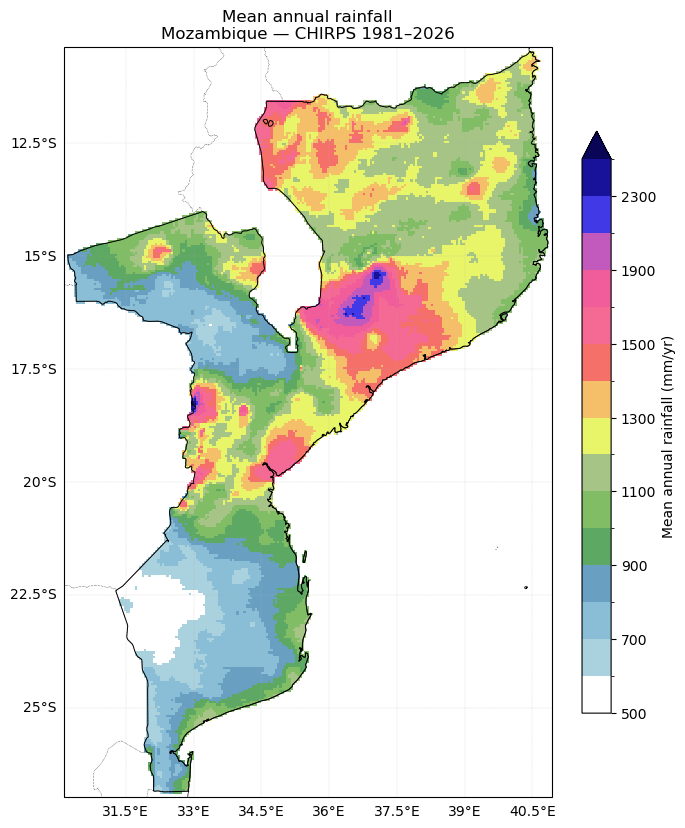

  Saved: 03_mean_annual_rainfall.png


In [47]:
# ---------------------------------------------------------------------------
# Step 4 — Spatial analysis
# ---------------------------------------------------------------------------
precip_cmap, precip_norm = make_cmap(very_high_vals=True)
# Mozambique boundary for overlaying on maps
shpfilename = shpreader.natural_earth(resolution="10m",
                                      category="cultural",
                                      name="admin_0_countries")
reader = shpreader.Reader(shpfilename)
moz_geom = next(
    r.geometry for r in reader.records()
    if r.attributes["ADMIN"] == "Mozambique"
)

def add_moz_boundary(ax):
    """Overlay Mozambique border on a Cartopy axes."""
    ax.add_geometries([moz_geom], crs=ccrs.PlateCarree(),
                      facecolor="none", edgecolor="black", linewidth=0.7)

extent = [lons.min()-0.1, lons.max()+0.1, lats.min()-0.1, lats.max()+0.1]
proj   = ccrs.PlateCarree()

# ── 4a. Mean annual rainfall map
mean_annual = np.nanmean(chirps_data, axis=0) * 12      # monthly mean → annual

fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={"projection": proj})
ax.set_extent(extent, crs=proj)
im = ax.pcolormesh(lons, lats, mean_annual,  cmap=precip_cmap, norm=precip_norm)
add_moz_boundary(ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)
gl.top_labels = gl.right_labels = False
plt.colorbar(im, ax=ax, orientation="vertical",
             label="Mean annual rainfall (mm/yr)", shrink=0.6, pad=0.05)
ax.set_title("Mean annual rainfall\nMozambique — CHIRPS 1981–2026", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join('../images/rainfall_viz', "03_mean_annual_rainfall.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: 03_mean_annual_rainfall.png")


C:\Coding\envs\soms-tc\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\963592580.py:4: RuntimeWarning: Mean of empty slice
  mean_map = np.nanmean(chirps_data, axis=0)


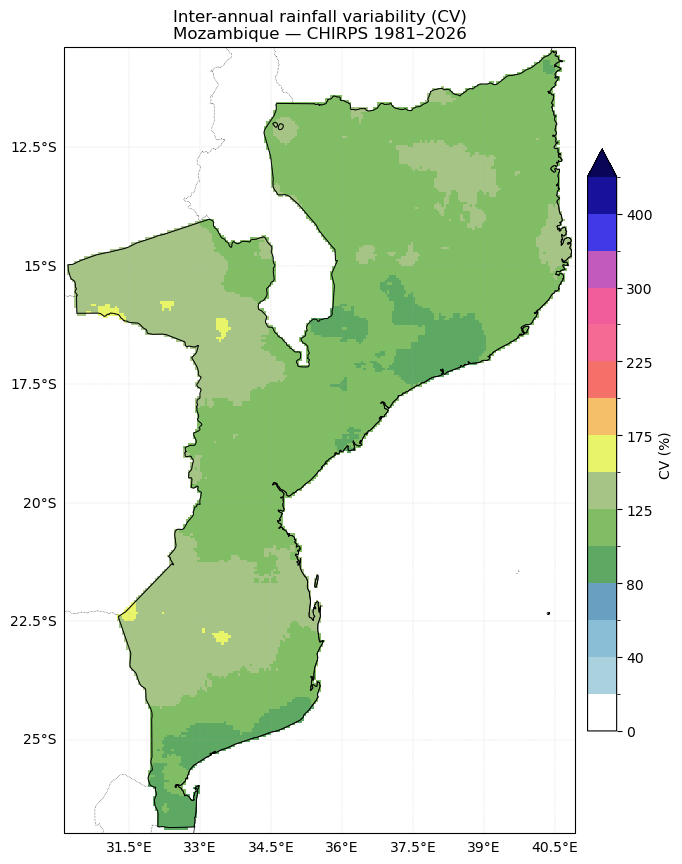

  Saved: 04_cv_map.png


C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\963592580.py:39: RuntimeWarning: Mean of empty slice
  vmax = max(vmax, np.nanmean(chirps_data[mask], axis=0).max())
C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\963592580.py:39: RuntimeWarning: Mean of empty slice
  vmax = max(vmax, np.nanmean(chirps_data[mask], axis=0).max())
C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\963592580.py:39: RuntimeWarning: Mean of empty slice
  vmax = max(vmax, np.nanmean(chirps_data[mask], axis=0).max())
C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\963592580.py:39: RuntimeWarning: Mean of empty slice
  vmax = max(vmax, np.nanmean(chirps_data[mask], axis=0).max())
C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\963592580.py:43: RuntimeWarning: Mean of empty slice
  season_map = np.nanmean(chirps_data[mask], axis=0)
C:\Users\HP ZBOOK\AppData\Local\Temp\ipykernel_47576\963592580.py:43: RuntimeWarning: Mean of empty slice
  season_map = np.nanmean(chirps_data[mask], axis=0)
C:

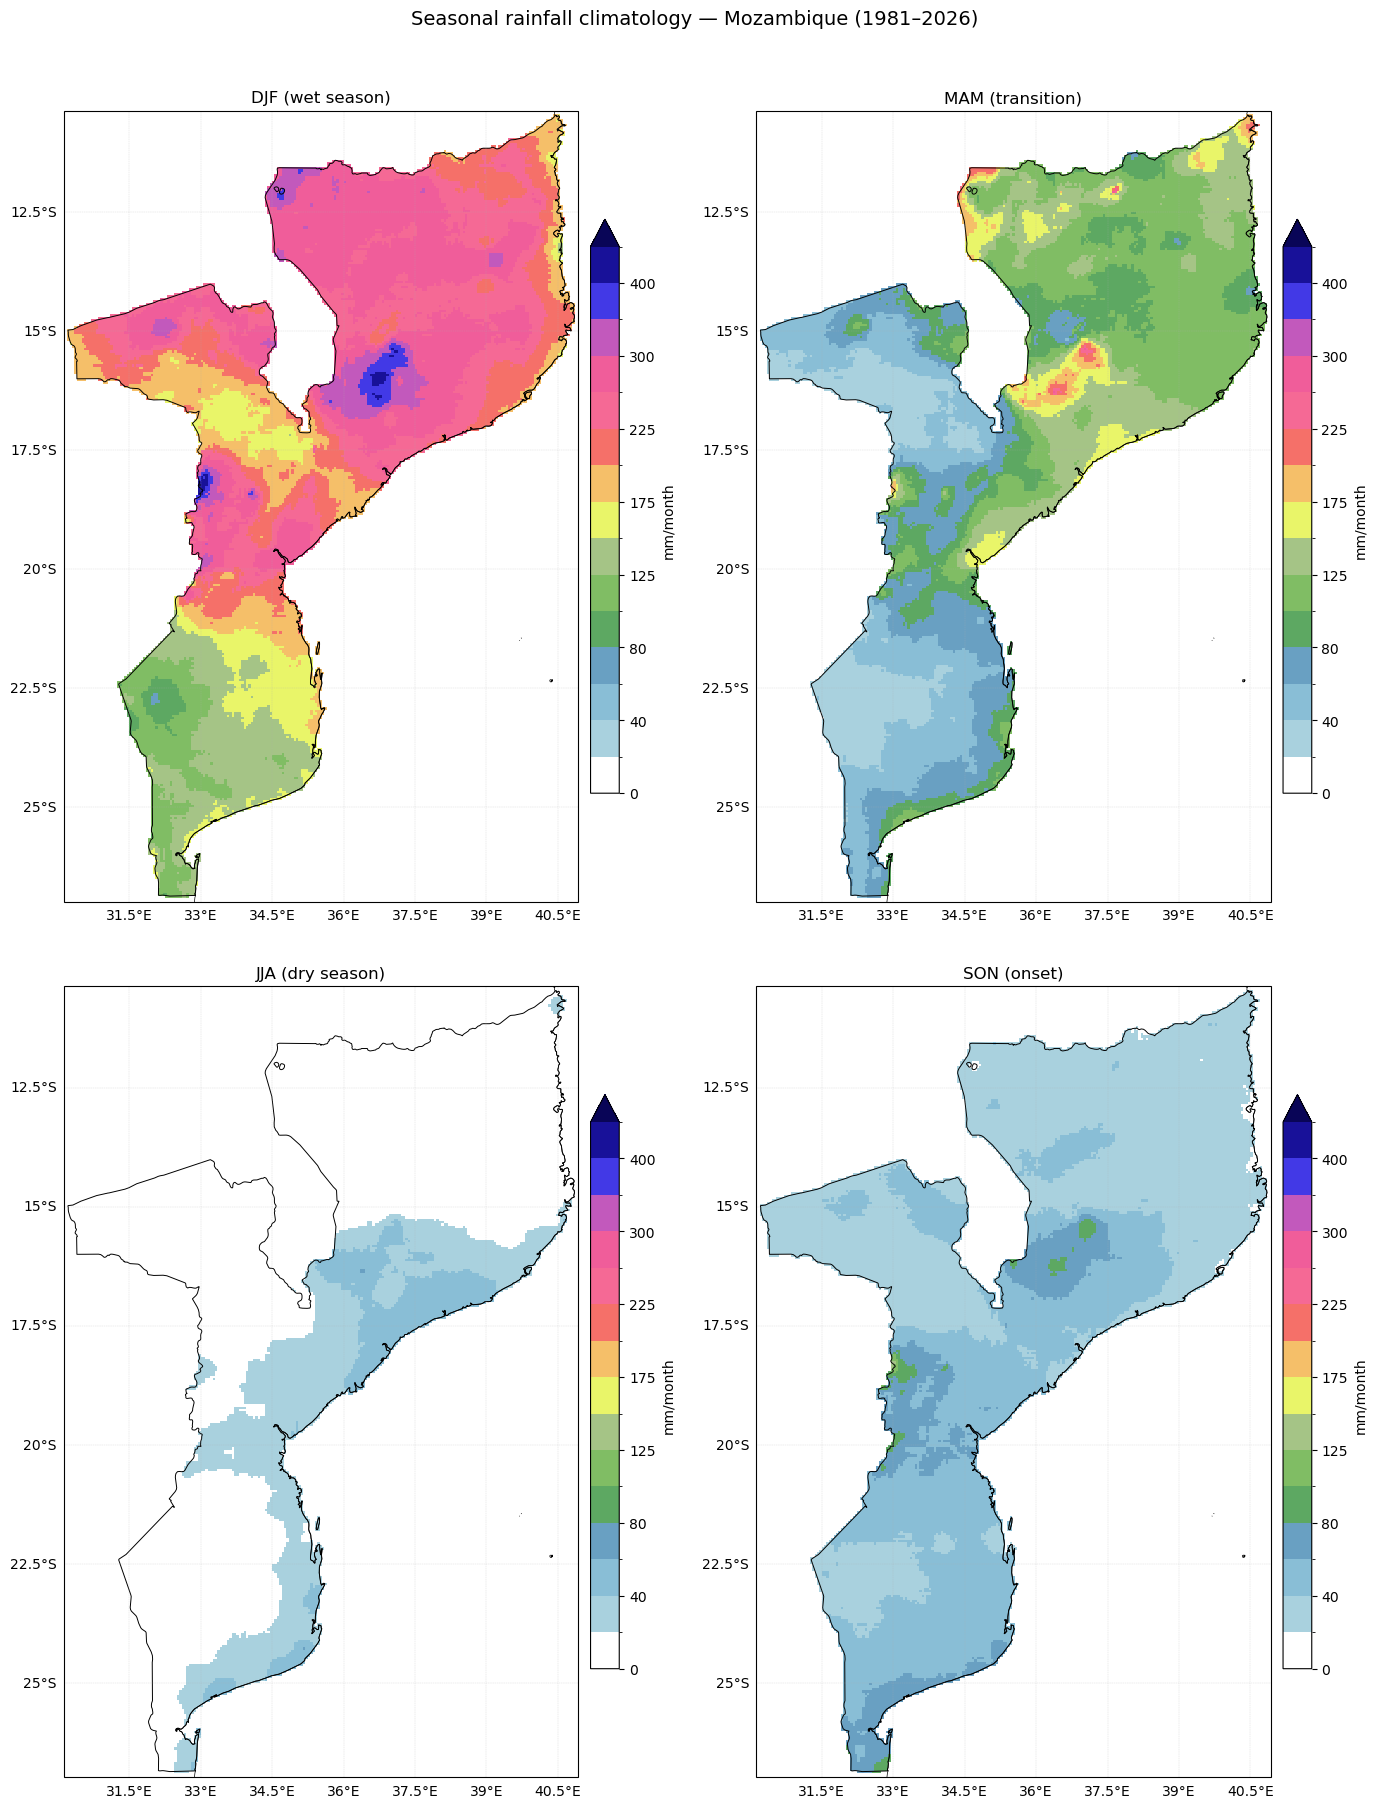

  Saved: 05_seasonal_maps.png


In [59]:
precip_cmap, precip_norm = make_cmap(high_vals=True)
# ── 4b. Coefficient of variation (inter-annual variability)
std_map  = np.nanstd(chirps_data, axis=0)
mean_map = np.nanmean(chirps_data, axis=0)
cv_map   = np.where(mean_map > 0, (std_map / mean_map) * 100, np.nan)

fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={"projection": proj})
ax.set_extent(extent, crs=proj)
im = ax.pcolormesh(lons, lats, cv_map, transform=proj,
                   cmap=precip_cmap, norm=precip_norm)
add_moz_boundary(ax)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)
gl.top_labels = gl.right_labels = False
plt.colorbar(im, ax=ax, orientation="vertical",
             label="CV (%)", shrink=0.6, pad=0.02)
ax.set_title("Inter-annual rainfall variability (CV)\nMozambique — CHIRPS 1981–2026", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join('../images/rainfall_viz', "04_cv_map.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: 04_cv_map.png")

# ── 4c. Seasonal maps (DJF, MAM, JJA, SON)
seasons = {
    "DJF (wet season)" : [12, 1, 2],
    "MAM (transition)"  : [3, 4, 5],
    "JJA (dry season)"  : [6, 7, 8],
    "SON (onset)"       : [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 18),
                         subplot_kw={"projection": proj})
axes = axes.flatten()

vmax = 0
for months in seasons.values():
    mask = np.isin(chirps_times.month, months)
    vmax = max(vmax, np.nanmean(chirps_data[mask], axis=0).max())

for ax, (season_name, months) in zip(axes, seasons.items()):
    mask       = np.isin(chirps_times.month, months)
    season_map = np.nanmean(chirps_data[mask], axis=0)
    ax.set_extent(extent, crs=proj)
    im = ax.pcolormesh(lons, lats, season_map, transform=proj,
                      cmap=precip_cmap, norm=precip_norm)
    add_moz_boundary(ax)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(im, ax=ax, label="mm/month", shrink=0.7, pad=0.02)
    ax.set_title(season_name, fontsize=12)

fig.suptitle("Seasonal rainfall climatology — Mozambique (1981–2026)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join('../images/rainfall_viz', "05_seasonal_maps.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: 05_seasonal_maps.png")